Rasterizing streets...
Rasterizing buildings...
Conversion complete!


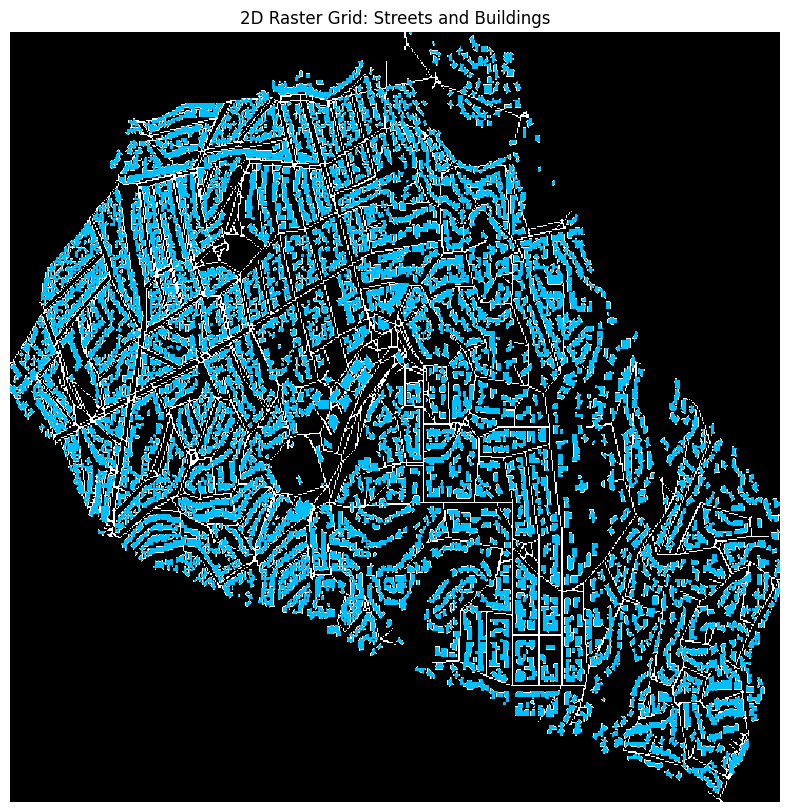

In [9]:
import osmnx as ox
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from skimage.draw import line, polygon

# 1. Download Data (Streets AND Buildings)
place_name = "Piedmont, California, USA"
print("Downloading streets...")
G = ox.graph_from_place(place_name, network_type='walk')
nodes, edges = ox.graph_to_gdfs(G)

print("Downloading buildings...")
# In modern OSMnx, we use features_from_place to get map features like buildings
buildings = ox.features_from_place(place_name, tags={'building': True})

# 2. Find the bounding box based on the street nodes
min_x, max_x = nodes['x'].min(), nodes['x'].max()
min_y, max_y = nodes['y'].min(), nodes['y'].max()

# 3. Define the Grid (0=Background, 1=Street, 2=Building)
grid_size = 500
grid = np.zeros((grid_size, grid_size), dtype=int) 

# Helper function to convert coordinates
def coord_to_grid(x, y, min_x, max_x, min_y, max_y, size):
    norm_x = (x - min_x) / (max_x - min_x)
    norm_y = (y - min_y) / (max_y - min_y)
    col = int(norm_x * (size - 1))
    row = int((1 - norm_y) * (size - 1))
    return row, col

# 4. Draw Streets (Value = 1)
print("Rasterizing streets...")
for _, row_data in edges.iterrows():
    u, v = row_data.name[0], row_data.name[1]
    start_x, start_y = nodes.loc[u, 'x'], nodes.loc[u, 'y']
    end_x, end_y = nodes.loc[v, 'x'], nodes.loc[v, 'y']
    
    start_row, start_col = coord_to_grid(start_x, start_y, min_x, max_x, min_y, max_y, grid_size)
    end_row, end_col = coord_to_grid(end_x, end_y, min_x, max_x, min_y, max_y, grid_size)
    
    rr, cc = line(start_row, start_col, end_row, end_col)
    grid[rr, cc] = 1

# 5. Draw Buildings (Value = 2)
print("Rasterizing buildings...")
for _, building in buildings.iterrows():
    # OSM data sometimes returns Points or MultiPolygons. We only want simple Polygons for this PoC.
    if building.geometry.geom_type == 'Polygon':
        # Get the X and Y coordinates of the building's exterior walls
        x_coords, y_coords = building.geometry.exterior.xy
        
        # Convert all corner coordinates to grid rows and columns
        grid_rows = []
        grid_cols = []
        for x, y in zip(x_coords, y_coords):
            r, c = coord_to_grid(x, y, min_x, max_x, min_y, max_y, grid_size)
            grid_rows.append(r)
            grid_cols.append(c)
            
        # Draw the filled polygon onto the grid
        rr, cc = polygon(grid_rows, grid_cols, shape=grid.shape)
        grid[rr, cc] = 2

print("Conversion complete!")

# 6. Visualize with custom colors
# 0: Black (Background), 1: White (Streets), 2: Deep Sky Blue (Buildings)
cmap = ListedColormap(['black', 'white', 'deepskyblue'])

plt.figure(figsize=(10, 10))
plt.imshow(grid, cmap=cmap)
plt.title("2D Raster Grid: Streets and Buildings")
plt.axis('off')
plt.show()